# Predicting Housing Prices and Housing Condition in King County

This notebook analyzes housing sales data from King County, Washington.

Goals of the project:

1. Predict housing prices using regression models
2. Predict whether a house is in **Great** or **Not Great** condition using classification


1. Data loading
2. Data cleaning and feature engineering
3. Exploratory Data Analysis
4. Model training
5. Model evaluation
6. Model comparison
7. Hyperparameter tuning

Models used:

- Linear Regression
- Logistic Regression
- Random Forest
- Tuned Random Forest (GridSearchCV)

In [155]:
# Load Packages

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    accuracy_score,
    classification_report
)

# Grid search for hyperparameter tuning
from sklearn.model_selection import GridSearchCV

In [157]:
# Path to dataset
DATA_PATH = Path("house_data.csv")

# Load dataset into pandas dataframe
df = pd.read_csv(DATA_PATH)

# Inspect dataset dimensions
print(df.shape)

# Display first rows
df.head()

(21613, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [159]:
# Display column information including data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [161]:
# Summary statistics for numeric variables
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,21613.0,4.580302e+09,2.876566e+09,1.000102e+06,2.123049e+09,3.904930e+09,7.308900e+09,9.900000e+09
price,21613.0,5.400881e+05,3.671272e+05,7.500000e+04,3.219500e+05,4.500000e+05,6.450000e+05,7.700000e+06
bedrooms,21613.0,3.370842e+00,9.300618e-01,0.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.300000e+01
bathrooms,21613.0,2.114757e+00,7.701632e-01,0.000000e+00,1.750000e+00,2.250000e+00,2.500000e+00,8.000000e+00
sqft_living,21613.0,2.079900e+03,9.184409e+02,2.900000e+02,1.427000e+03,1.910000e+03,2.550000e+03,1.354000e+04
sqft_lot,21613.0,1.510697e+04,4.142051e+04,5.200000e+02,5.040000e+03,7.618000e+03,1.068800e+04,1.651359e+06
floors,21613.0,1.494309e+00,5.399889e-01,1.000000e+00,1.000000e+00,1.500000e+00,2.000000e+00,3.500000e+00
waterfront,21613.0,7.541757e-03,8.651720e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
view,21613.0,2.343034e-01,7.663176e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
condition,21613.0,3.409430e+00,6.507430e-01,1.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00


In [7]:
df.isna().sum().sort_values(ascending=False)

id               0
grade            0
sqft_living15    0
long             0
lat              0
zipcode          0
yr_renovated     0
yr_built         0
sqft_basement    0
sqft_above       0
condition        0
date             0
view             0
waterfront       0
floors           0
sqft_lot         0
sqft_living      0
bathrooms        0
bedrooms         0
price            0
sqft_lot15       0
dtype: int64

## Data Cleaning and Feature Engineering

The original dataset contains several raw variables that can be simplified or re-expressed for modeling.

This section creates the main engineered features used in the analysis:

- `last_updated`: the most recent year a house was built or renovated
- `condition_cat`: binary condition label (`Great` vs `Not Great`)
- `view_cat`: categorical version of the view score
- `waterfront_cat`: categorical waterfront indicator

It also removes variables that are either identifiers, redundant with other variables, or less useful for the final modeling workflow.

In [9]:
df_model = df.copy()

In [163]:
# Create working copy of dataframe so original data is preserved
df_model = df.copy()

# Create a variable representing the most recent update year of the house.
# If the house was never renovated, we use the year built.
df_model["last_updated"] = np.where(
    df_model["yr_renovated"] == 0,
    df_model["yr_built"],
    df_model["yr_renovated"]
)

# Create binary condition category used in logistic regression
# Houses with condition > 3 are considered "Great"
df_model["condition_cat"] = np.where(
    df_model["condition"] > 3,
    "Great",
    "Not Great"
)

# Convert view rating to categorical variable
df_model["view_cat"] = df_model["view"].astype("category")

# Convert waterfront indicator to categorical variable
df_model["waterfront_cat"] = np.where(
    df_model["waterfront"] == 1,
    "Yes",
    "No"
)

df_model["waterfront_cat"] = df_model["waterfront_cat"].astype("category")

In [11]:
df_model[["yr_built", "yr_renovated", "last_updated", "condition", "condition_cat", "view_cat", "waterfront_cat"]].head()

,yr_built,yr_renovated,last_updated,condition,condition_cat,view_cat,waterfront_cat
0,1955,0,1955,3,Not Great,0,No
1,1951,1991,1991,3,Not Great,0,No
2,1933,0,1933,3,Not Great,0,No
3,1965,0,1965,5,Great,0,No
4,1987,0,1987,3,Not Great,0,No


In [165]:
# These variables are removed because:
# - some are identifiers (id)
# - some are redundant with engineered features
# - some are less useful for modeling

columns_to_drop = [
    "id",
    "date",
    "yr_built",
    "yr_renovated",
    "zipcode",
    "condition",
    "sqft_above",
    "sqft_basement",
    "view",
    "waterfront"
]

df_model = df_model.drop(columns=columns_to_drop)

In [13]:
print(df_model.shape)
print(df_model.columns)

(21613, 15)
Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'grade', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'last_updated',
       'condition_cat', 'view_cat', 'waterfront_cat'],
      dtype='object')


### Data Quality Checks

Before modeling, it is useful to inspect the dataset for duplicates, missing values, and unusual observations that may affect model quality.

In [15]:
duplicate_count = df_model.duplicated().sum()
print(f"Duplicate rows: {duplicate_count}")

Duplicate rows: 5


In [16]:
df_model.isna().sum().sort_values(ascending=False)

price             0
bedrooms          0
bathrooms         0
sqft_living       0
sqft_lot          0
floors            0
grade             0
lat               0
long              0
sqft_living15     0
sqft_lot15        0
last_updated      0
condition_cat     0
view_cat          0
waterfront_cat    0
dtype: int64

In [17]:
df_model.sort_values("bedrooms", ascending=False)[
    ["price", "bedrooms", "bathrooms", "sqft_living", "floors", "condition_cat", "last_updated"]
].head(10)

,price,bedrooms,bathrooms,sqft_living,floors,condition_cat,last_updated
15870,640000.0,33,1.75,1620,1.0,Great,1947
8757,520000.0,11,3.00,3000,2.0,Not Great,1999
15161,650000.0,10,2.00,3610,2.0,Great,1958
13314,1148000.0,10,5.25,4590,1.0,Not Great,2008
19254,660000.0,10,3.00,2920,2.0,Great,1913
8546,450000.0,9,7.50,4050,2.0,Not Great,1996
4096,599999.0,9,4.50,3830,2.5,Not Great,1938
4235,700000.0,9,3.00,3680,2.0,Not Great,1908
16844,1400000.0,9,4.00,4620,2.5,Not Great,1915
6079,1280000.0,9,4.50,3650,2.0,Not Great,2010


## Define Modeling Targets

This project includes two separate supervised learning tasks:

1. **Regression task**: predict `price`
2. **Classification task**: predict `condition_cat`

The same cleaned dataset is used to prepare both tasks, with task-specific predictors defined below.

In [19]:
df_reg = df_model.copy()

In [20]:
# use log price as a predictor
df_clf = df_model.copy()
df_clf["log_price"] = np.log(df_clf["price"])

In [21]:
print("Regression shape:", df_reg.shape)
print("Classification shape:", df_clf.shape)

Regression shape: (21613, 15)
Classification shape: (21613, 16)


## Exploratory Data Analysis

This section examines the distribution of housing prices and several relationships that are likely to matter for price prediction and condition classification.

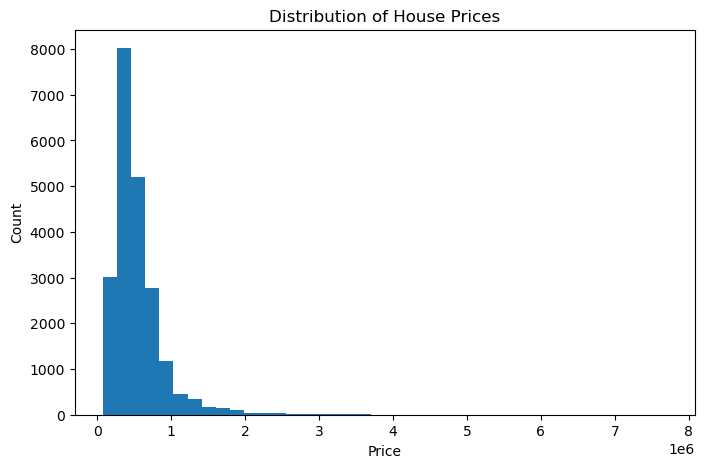

In [23]:
plt.figure(figsize=(8, 5))
plt.hist(df_reg["price"], bins=40)
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Distribution of House Prices")
plt.show()

Housing prices are right-skewed, meaning there are relatively few very expensive houses.

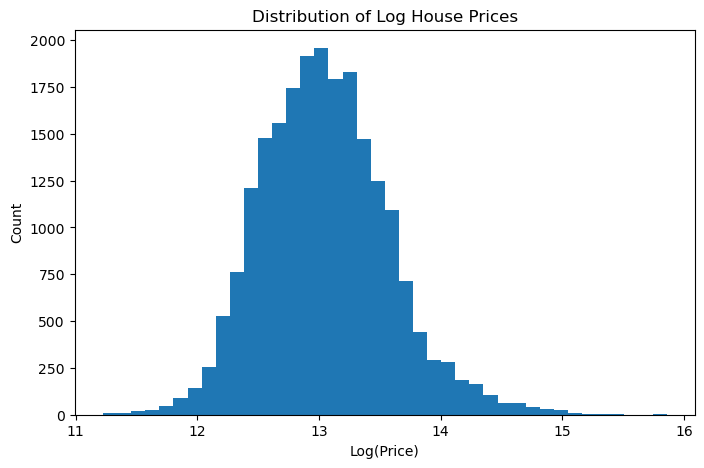

In [24]:
plt.figure(figsize=(8, 5))
plt.hist(np.log(df_reg["price"]), bins=40)
plt.xlabel("Log(Price)")
plt.ylabel("Count")
plt.title("Distribution of Log House Prices")
plt.show()

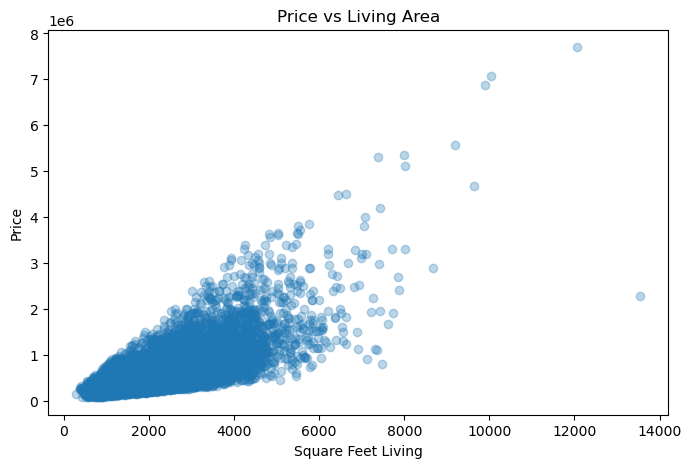

In [25]:
plt.figure(figsize=(8, 5))
plt.scatter(df_reg["sqft_living"], df_reg["price"], alpha=0.3)
plt.xlabel("Square Feet Living")
plt.ylabel("Price")
plt.title("Price vs Living Area")
plt.show()

Living area shows a strong positive relationship with housing price, which is expected because larger homes generally sell for higher prices.

In [26]:
df_clf["condition_cat"].value_counts()

condition_cat
Not Great    14233
Great         7380
Name: count, dtype: int64

## Train/Test Split and Modeling Setup

To evaluate predictive performance, the dataset is split into training and testing sets.

- The **training set** is used for visualization, model building, and model tuning.
- The **test set** is reserved for evaluating predictive performance on unseen data.


1. **Multiple Linear Regression** to predict housing price.
2. **Logistic Regression** to classify housing condition (`Great` vs `Not Great`).

In [30]:
# regression predictors

target_reg = "price"

features_reg = [
    "bedrooms",
    "bathrooms",
    "sqft_living",
    "sqft_lot",
    "floors",
    "grade",
    "lat",
    "long",
    "sqft_living15",
    "sqft_lot15",
    "last_updated",
    "view_cat",
    "waterfront_cat"
]

X_reg = df_reg[features_reg]
y_reg = df_reg[target_reg]

The model is trained on 80% of the data and evaluated on the remaining 20%.
This prevents data leakage.

**Data leakage** is a modeling error where information that would not be available at prediction time is unintentionally used during training. This causes the model to appear highly accurate during evaluation but perform poorly in real-world use.

In [31]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=18
)

In [32]:
## Identify categorical and numeric variables
categorical_features_reg = [
    "view_cat",
    "waterfront_cat"
]

numeric_features_reg = [
    col for col in features_reg if col not in categorical_features_reg
]

In [33]:
# preprocessing pipeline

# Numeric preprocessing pipeline
# Missing values are filled with median
# Features are standardized

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing pipeline
# Missing values filled with most frequent category
# One-hot encoding converts categories to binary indicators

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first"))
])

# Combine preprocessing steps

preprocessor_reg = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features_reg),
    ("cat", categorical_pipeline, categorical_features_reg)
])

In [34]:
regression_model = Pipeline([
    ("preprocess", preprocessor_reg),
    ("model", LinearRegression())
])

In [35]:
regression_model.fit(X_train_reg, y_train_reg)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['bedrooms', 'bathrooms',
                                                   'sqft_living', 'sqft_lot',
                                                   'floors', 'grade', 'lat',
                                                   'long', 'sqft_living15',
                                                   'sqft_lot15',
                                                   'last_updated']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first'))]),
                                                  ['view_cat',
                                                   'waterfront_cat'])])),
                ('model', LinearRegression())])

## Linear Regression Model Evaluation

After fitting the regression model on the training data, we evaluate its predictive performance on the held-out test set.

The following metrics are used:

- **Mean Squared Error (MSE)** (RMSE measures typical prediction error in dollars)
- **Root Mean Squared Error (RMSE)** (MAE measures average absolute prediction error)
- **Mean Absolute Error (MAE)** (R² measures proportion of variance explained)
- **R² Score** (Higher R² and lower errors indicate better performance)


In [37]:
y_pred_reg = regression_model.predict(X_test_reg)

In [38]:
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

print("Regression Performance")
print("----------------------")
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R²:", r2)

Regression Performance
----------------------
MSE: 37831000596.329445
RMSE: 194501.92954397507
MAE: 128222.16224567244
R²: 0.6978453823103203


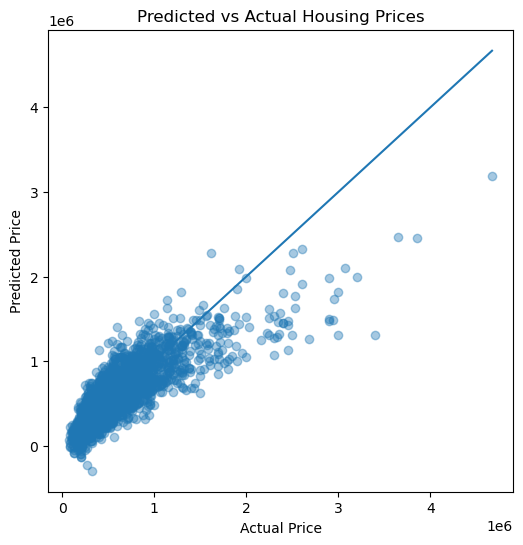

In [39]:
plt.figure(figsize=(6,6))

plt.scatter(y_test_reg, y_pred_reg, alpha=0.4)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual Housing Prices")

plt.plot(
    [y_test_reg.min(), y_test_reg.max()],
    [y_test_reg.min(), y_test_reg.max()],
)

plt.show()

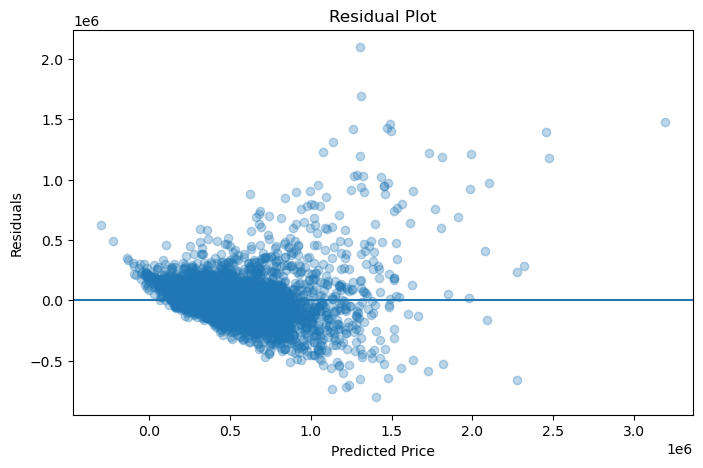

In [40]:
residuals = y_test_reg - y_pred_reg

plt.figure(figsize=(8,5))

plt.scatter(y_pred_reg, residuals, alpha=0.3)

plt.axhline(0)

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

## Logistic Regression Model

The second modeling task predicts whether a house is in **Great** or **Not Great** condition.


In [42]:
# classification predictors

target_clf = "condition_cat"

features_clf = [
    "log_price",
    "sqft_living",
    "sqft_lot",
    "floors",
    "grade",
    "lat",
    "long",
    "sqft_living15",
    "sqft_lot15",
    "last_updated",
    "view_cat",
    "waterfront_cat",
    "bathrooms",
    "bedrooms"
]

X_clf = df_clf[features_clf]
y_clf = df_clf[target_clf]

In [43]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=18
)

In [44]:
categorical_features_clf = [
    "view_cat",
    "waterfront_cat"
]

numeric_features_clf = [
    col for col in features_clf if col not in categorical_features_clf
]

In [45]:
preprocessor_clf = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features_clf),
    ("cat", categorical_pipeline, categorical_features_clf)
])

In [46]:
logistic_model = Pipeline([
    ("preprocess", preprocessor_clf),
    ("model", LogisticRegression(max_iter=2000))
])

In [47]:
logistic_model.fit(X_train_clf, y_train_clf)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['log_price', 'sqft_living',
                                                   'sqft_lot', 'floors',
                                                   'grade', 'lat', 'long',
                                                   'sqft_living15',
                                                   'sqft_lot15', 'last_updated',
                                                   'bathrooms', 'bedrooms']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first'))]),
                                                  ['view_cat',
                                                   'waterfront_cat'])])),
                ('model', LogisticRegression(max_iter=2000))])

## Logistic Regression Model Evaluation

The logistic regression model predicts whether a home is in **Great** or **Not Great** condition.

Model performance is evaluated using:

- Accuracy
- Confusion matrix
- Classification report
- ROC curve
- AUC score

In [49]:
y_pred_clf = logistic_model.predict(X_test_clf)
y_prob_clf = logistic_model.predict_proba(X_test_clf)[:,1]

In [50]:
accuracy = accuracy_score(y_test_clf, y_pred_clf)

print("Classification Accuracy:", accuracy)

Classification Accuracy: 0.724265556326625


In [51]:
cm = confusion_matrix(y_test_clf, y_pred_clf)

print("Confusion Matrix")
print(cm)

Confusion Matrix
[[ 738  737]
 [ 455 2393]]


In [52]:
print(classification_report(y_test_clf, y_pred_clf))

              precision    recall  f1-score   support

       Great       0.62      0.50      0.55      1475
   Not Great       0.76      0.84      0.80      2848

    accuracy                           0.72      4323
   macro avg       0.69      0.67      0.68      4323
weighted avg       0.71      0.72      0.72      4323



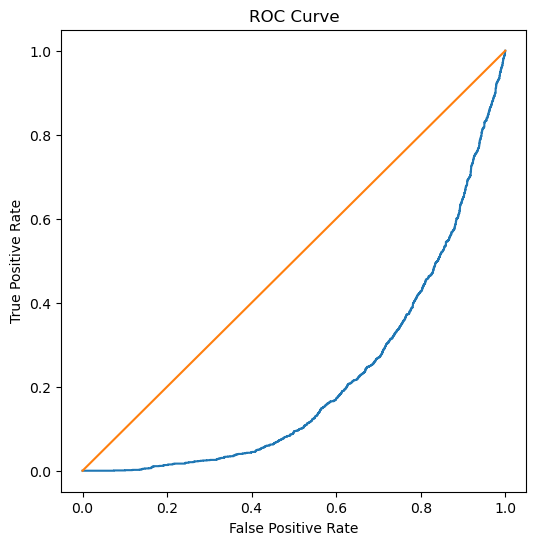

In [53]:
fpr, tpr, thresholds = roc_curve(y_test_clf == "Great", y_prob_clf)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr)

plt.plot([0,1],[0,1])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

In [54]:
pos_class_index = list(logistic_model.classes_).index("Great")

y_prob_clf = logistic_model.predict_proba(X_test_clf)[:, pos_class_index]

auc = roc_auc_score(y_test_clf == "Great", y_prob_clf)

print("ROC AUC:", auc)

ROC AUC: 0.7834429156351173


**AUC (Area Under the Curve)** refers to the area under the ROC curve in binary classification. It measures how well a model separates the two classes.

The ROC curve plots:

True Positive Rate (TPR) = Recall = TP / (TP + FN)

False Positive Rate (FPR) = FP / (FP + TN)

AUC = area under the ROC curve

Range: 0 to 1

Interpretation:

1.0 → perfect model

0.5 → random guessing

< 0.5 → worse than random (predicting backwards)

## Key Findings

### Housing Price Prediction

- Living area (square footage) is the strongest predictor of price.
- Geographic location (latitude and longitude) plays a major role in determining housing value.
- Housing quality indicators such as **grade** and **waterfront access** are strongly associated with higher prices.

### Housing Condition Classification

- Homes with more recent updates tend to fall into the **Great condition** category.
- Structural characteristics such as floor count and square footage help distinguish better-maintained homes.


# New

## Random Forest Price Prediction

To compare the baseline linear regression model with a more flexible machine learning approach, this section fits a Random Forest Regressor.

Random forests can capture nonlinear relationships and interactions between housing features without requiring them to be specified manually. This makes them a useful benchmark for structured tabular prediction tasks such as housing price estimation.

In [58]:
from sklearn.ensemble import RandomForestRegressor

In [59]:
random_forest_model = Pipeline([
    ("preprocess", preprocessor_reg),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=18,
        n_jobs=-1
    ))
])

In [60]:
random_forest_model.fit(X_train_reg, y_train_reg)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['bedrooms', 'bathrooms',
                                                   'sqft_living', 'sqft_lot',
                                                   'floors', 'grade', 'lat',
                                                   'long', 'sqft_living15',
                                                   'sqft_lot15',
                                                   'last_updated']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first'))]),
                                                  ['view_cat',
                                                   'waterfront_cat'])])),
                ('model',
                 RandomForestRegressor(min_samples_leaf=2, min_samples_split=5,
                                       n_estimators=300, n_jobs=-1,
                                       random_state=18))])

In [61]:
y_pred_rf = random_forest_model.predict(X_test_reg)

In [62]:
mse_rf = mean_squared_error(y_test_reg, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test_reg, y_pred_rf)
r2_rf = r2_score(y_test_reg, y_pred_rf)

print("Random Forest Regression Performance")
print("-----------------------------------")
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("MAE:", mae_rf)
print("R²:", r2_rf)

Random Forest Regression Performance
-----------------------------------
MSE: 14833207289.150633
RMSE: 121791.65525252801
MAE: 68523.87472466592
R²: 0.8815277944829211


In [63]:
comparison_df = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "RMSE": [rmse, rmse_rf],
    "MAE": [mae, mae_rf],
    "R²": [r2, r2_rf]
})

comparison_df

,Model,RMSE,MAE,R²
0,Linear Regression,194501.929544,128222.162246,0.697845
1,Random Forest,121791.655253,68523.874725,0.881528


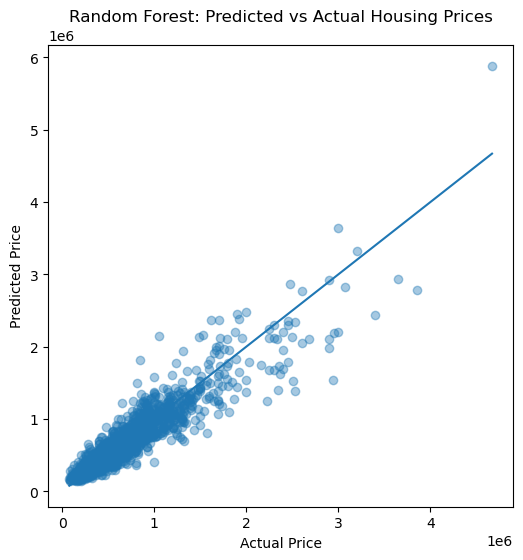

In [64]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_reg, y_pred_rf, alpha=0.4)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest: Predicted vs Actual Housing Prices")
plt.plot(
    [y_test_reg.min(), y_test_reg.max()],
    [y_test_reg.min(), y_test_reg.max()]
)
plt.show()

### Random Forest Feature Importance

Unlike linear regression, random forests can provide an importance ranking of features based on how much they improve prediction across the ensemble of trees.

In [66]:
ohe = random_forest_model.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"]

encoded_cat_features = ohe.get_feature_names_out(categorical_features_reg)
all_feature_names = numeric_features_reg + list(encoded_cat_features)

feature_importance = pd.DataFrame({
    "feature": all_feature_names,
    "importance": random_forest_model.named_steps["model"].feature_importances_
}).sort_values("importance", ascending=False)

feature_importance.head(15)

,feature,importance
2,sqft_living,0.352007
5,grade,0.259733
6,lat,0.173188
7,long,0.078028
8,sqft_living15,0.037140
15,waterfront_cat_Yes,0.032386
3,sqft_lot,0.017054
9,sqft_lot15,0.015680
10,last_updated,0.014194
1,bathrooms,0.007092


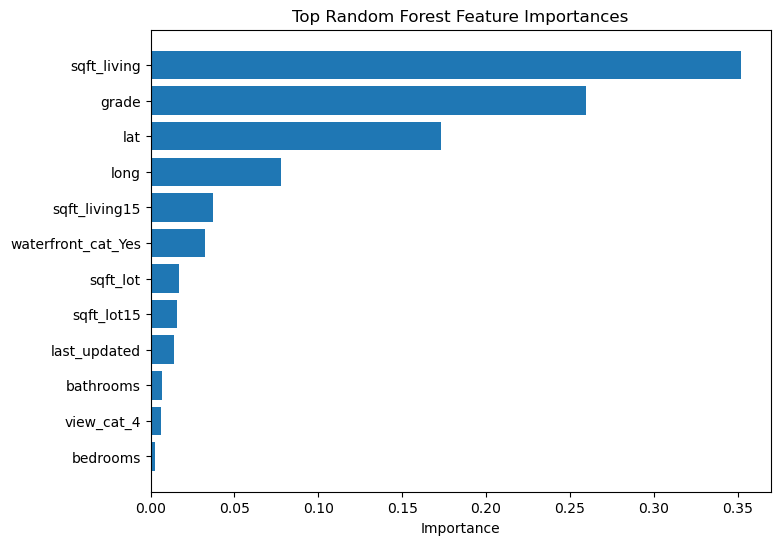

In [67]:
top_features = feature_importance.head(12).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Importance")
plt.title("Top Random Forest Feature Importances")
plt.show()

## Hyperparameter Tuning with GridSearchCV

To improve Random Forest performance, this section uses cross-validated hyperparameter tuning with `GridSearchCV`.

Rather than relying on one manually chosen configuration, grid search evaluates multiple combinations of model settings and selects the one with the best cross-validated performance on the training set.

In [69]:
from sklearn.model_selection import GridSearchCV

In [70]:
rf_pipeline = Pipeline([
    ("preprocess", preprocessor_reg),
    ("model", RandomForestRegressor(random_state=18, n_jobs=-1))
])

In [ ]:
# Define the hyperparameter grid for GridSearchCV
param_grid = {
    
    # Number of trees in the forest
    # More trees → better performance (usually) but slower training
    "model__n_estimators": [100, 300],
    
    # Maximum depth of each tree
    # None → nodes expand until all leaves are pure (can overfit)
    # Smaller values → simpler trees, helps prevent overfitting
    "model__max_depth": [None, 10, 20],
    
    # Minimum number of samples required to split an internal node
    # Higher values → more conservative splits → less overfitting
    "model__min_samples_split": [2, 5],
    
    # Minimum number of samples required at a leaf node
    # Increasing this smooths the model and reduces variance
    "model__min_samples_leaf": [1, 2],
    
    # Number of features considered when looking for the best split
    # "sqrt" → common default for Random Forest
    # 0.8 → use 80% of features at each split (more aggressive feature usage)
    "model__max_features": ["sqrt", 0.8]
}

In [72]:
import warnings
warnings.filterwarnings("ignore")

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_reg, y_train_reg)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Int

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['bedrooms',
                                                                          'bathrooms',
                                                                          'sqft_living',
                                                                          'sqft_lot',
                                                                          'floors',
                                                                          'grade',
                                                                          'lat',
                                                                          'long',
                                                                          'sqft_living15',
                                                                          'sqft_lot15',
                                                                          'last_updated']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          Sim...
                                                                                          OneHotEncoder(drop='first'))]),
                                                                         ['view_cat',
                                                                          'waterfront_cat'])])),
                                       ('model',
                                        RandomForestRegressor(n_jobs=-1,
                                                              random_state=18))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 10, 20],
                         'model__max_features': ['sqrt', 0.8],
                         'model__min_samples_leaf': [1, 2],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 300]},
             scoring='neg_mean_squared_error', verbose=1)

In [73]:
# Best cross-validation score
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'model__max_depth': 20, 'model__max_features': 0.8, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 300}


In [74]:
# Convert the score back into RMSE
best_cv_rmse = np.sqrt(-grid_search.best_score_)
print("Best CV RMSE:", best_cv_rmse)

Best CV RMSE: 130307.4267664416


In [75]:
best_rf_model = grid_search.best_estimator_

y_pred_rf_tuned = best_rf_model.predict(X_test_reg)

In [76]:
mse_rf_tuned = mean_squared_error(y_test_reg, y_pred_rf_tuned)
rmse_rf_tuned = np.sqrt(mse_rf_tuned)
mae_rf_tuned = mean_absolute_error(y_test_reg, y_pred_rf_tuned)
r2_rf_tuned = r2_score(y_test_reg, y_pred_rf_tuned)

print("Tuned Random Forest Performance")
print("-------------------------------")
print("MSE:", mse_rf_tuned)
print("RMSE:", rmse_rf_tuned)
print("MAE:", mae_rf_tuned)
print("R²:", r2_rf_tuned)

Tuned Random Forest Performance
-------------------------------
MSE: 14205893779.15737
RMSE: 119188.48006060557
MAE: 67928.08467809053
R²: 0.8865381212201413


In [77]:
comparison_df = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Tuned Random Forest"],
    "RMSE": [rmse, rmse_rf, rmse_rf_tuned],
    "MAE": [mae, mae_rf, mae_rf_tuned],
    "R²": [r2, r2_rf, r2_rf_tuned]
})

comparison_df.sort_values("RMSE")

,Model,RMSE,MAE,R²
2,Tuned Random Forest,119188.480061,67928.084678,0.886538
1,Random Forest,121791.655253,68523.874725,0.881528
0,Linear Regression,194501.929544,128222.162246,0.697845


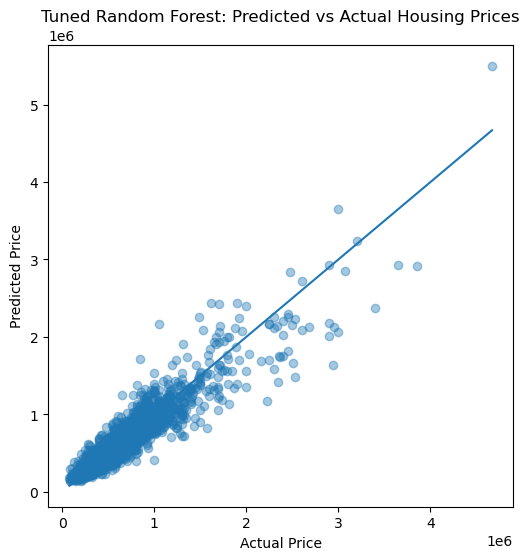

In [78]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_reg, y_pred_rf_tuned, alpha=0.4)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Tuned Random Forest: Predicted vs Actual Housing Prices")
plt.plot(
    [y_test_reg.min(), y_test_reg.max()],
    [y_test_reg.min(), y_test_reg.max()]
)
plt.show()

In [79]:
# Feature importance for tuned model

ohe_tuned = best_rf_model.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"]

encoded_cat_features_tuned = ohe_tuned.get_feature_names_out(categorical_features_reg)
all_feature_names_tuned = numeric_features_reg + list(encoded_cat_features_tuned)

feature_importance_tuned = pd.DataFrame({
    "feature": all_feature_names_tuned,
    "importance": best_rf_model.named_steps["model"].feature_importances_
}).sort_values("importance", ascending=False)

feature_importance_tuned.head(15)

,feature,importance
2,sqft_living,0.329277
5,grade,0.249269
6,lat,0.166076
7,long,0.078042
8,sqft_living15,0.052126
15,waterfront_cat_Yes,0.031884
10,last_updated,0.020666
3,sqft_lot,0.019299
9,sqft_lot15,0.018145
1,bathrooms,0.015868


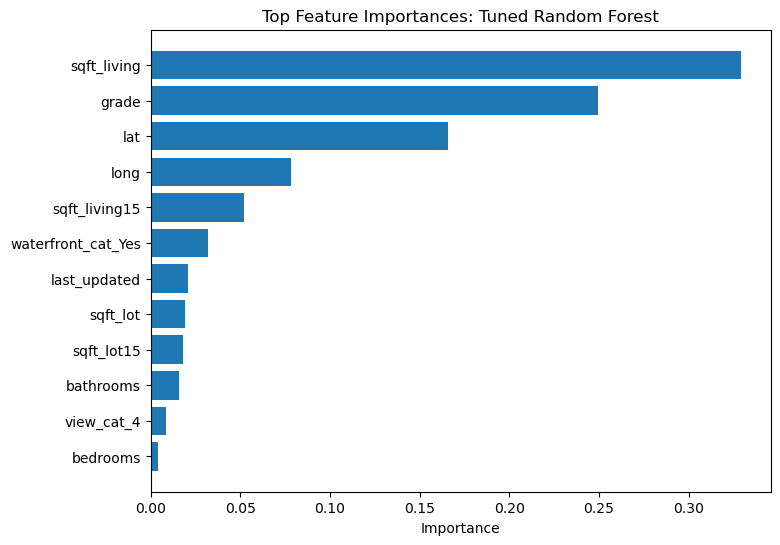

In [80]:
top_features_tuned = feature_importance_tuned.head(12).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(top_features_tuned["feature"], top_features_tuned["importance"])
plt.xlabel("Importance")
plt.title("Top Feature Importances: Tuned Random Forest")
plt.show()

Notes:

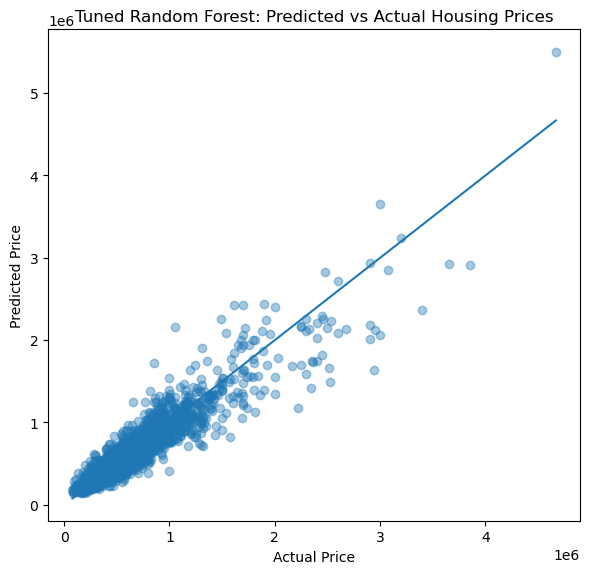

In [82]:
# predicted-vs-actual plot

from pathlib import Path

FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(6, 6))
plt.scatter(y_test_reg, y_pred_rf_tuned, alpha=0.4)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Tuned Random Forest: Predicted vs Actual Housing Prices")
plt.plot(
    [y_test_reg.min(), y_test_reg.max()],
    [y_test_reg.min(), y_test_reg.max()]
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "predicted_vs_actual.png", dpi=300, bbox_inches="tight")
plt.show()

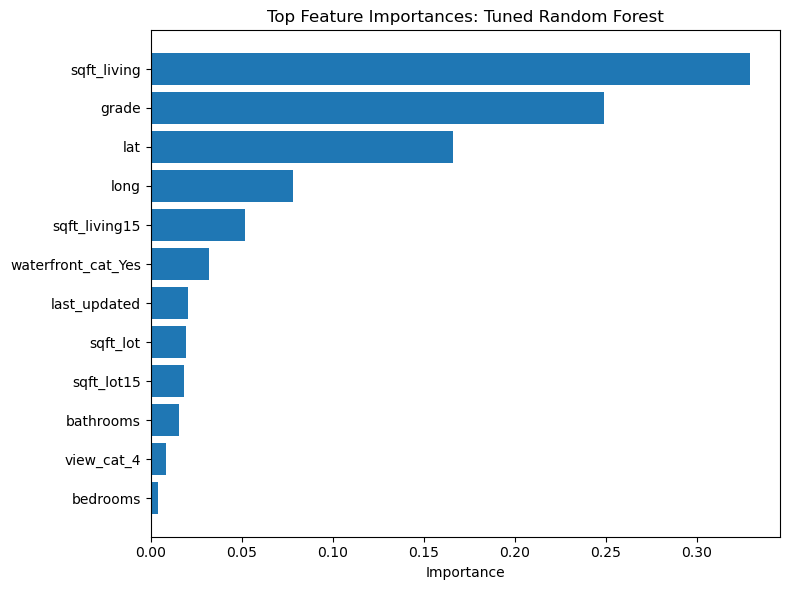

In [83]:
# feature importance plot

top_features_tuned = feature_importance_tuned.head(12).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(top_features_tuned["feature"], top_features_tuned["importance"])
plt.xlabel("Importance")
plt.title("Top Feature Importances: Tuned Random Forest")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

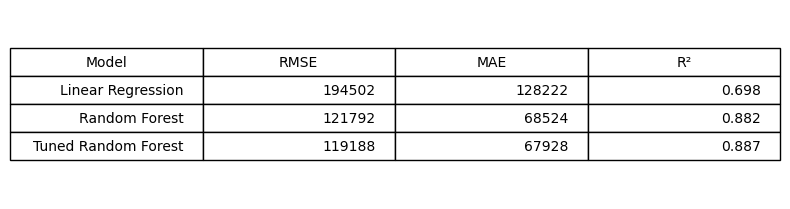

In [84]:
# model comparison

comparison_df_rounded = comparison_df.copy()
comparison_df_rounded["RMSE"] = comparison_df_rounded["RMSE"].round(0).astype(int)
comparison_df_rounded["MAE"] = comparison_df_rounded["MAE"].round(0).astype(int)
comparison_df_rounded["R²"] = comparison_df_rounded["R²"].round(3)

fig, ax = plt.subplots(figsize=(8, 2.2))
ax.axis("off")

table = ax.table(
    cellText=comparison_df_rounded.values,
    colLabels=comparison_df_rounded.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_comparison_table.png", dpi=300, bbox_inches="tight")
plt.show()